<div style="background: linear-gradient(135deg, #171520, #2c283f); padding: 32px; border-radius: 16px; border-left: 6px solid #ff7e5f; color: white; font-family: 'Segoe UI', system-ui, -apple-system, sans-serif; box-shadow: 0 12px 35px rgba(0,0,0,0.4); position: relative; overflow: hidden;">
<div style="position: absolute; top: -50px; right: -30px; width: 180px; height: 180px; background: #ff7e5f; opacity: 0.12; filter: blur(60px); border-radius: 50%;"></div>
<div style="position: absolute; bottom: -50px; left: 10%; width: 220px; height: 220px; background: #1a73e8; opacity: 0.12; filter: blur(70px); border-radius: 50%;"></div>
<div style="display: flex; justify-content: space-between; align-items: center; flex-wrap: wrap; gap: 25px; position: relative; z-index: 1;">
<div style="display: flex; align-items: center; gap: 24px;">
<div style="background: rgba(255, 255, 255, 0.04); padding: 14px; border-radius: 16px; border: 1px solid rgba(255, 255, 255, 0.1); backdrop-filter: blur(12px); display: flex; align-items: center; justify-content: center; width: 85px; height: 85px; box-shadow: 0 4px 15px rgba(0,0,0,0.2);">
<img src="logo.png" alt="Orbit of Ops Logo" style="max-width: 100%; max-height: 100%; object-fit: contain;" />
</div>
<div>
<h1 style="color: #ffffff; margin: 0; font-size: 2.3em; font-weight: 800; letter-spacing: 0.5px; text-shadow: 0 2px 5px rgba(0,0,0,0.3);">🪐 Orbit of Ops Workspace</h1>
<p style="font-size: 1.15em; color: #a5b4cb; margin-top: 8px; margin-bottom: 0; font-weight: 500;">Advanced AI Research Foundations &amp; <span style="color: #ffffff;">Small Language Model Laboratory</span></p>
</div>
</div>
<div style="background: rgba(255, 255, 255, 0.05); padding: 12px 22px; border-radius: 30px; border: 1px solid rgba(255, 255, 255, 0.15); backdrop-filter: blur(8px); box-shadow: 0 4px 15px rgba(0,0,0,0.15);">
<span style="font-size: 0.95em; display: flex; align-items: center; gap: 10px;">
<span style="font-size: 1.2em;">▶️</span>
<strong style="color: #e2e8f0; font-weight: 600;">YouTube &amp; Socials:</strong>
<code style="background: rgba(255, 126, 95, 0.15); color: #ff9b85; padding: 6px 12px; border-radius: 8px; font-weight: 700; font-family: 'Fira Code', ui-monospace, monospace; border: 1px solid rgba(255, 126, 95, 0.3);">@orbitofops</code>
</span>
</div>
</div>
<hr style="border: none; border-top: 1px solid rgba(255, 255, 255, 0.12); margin: 28px 0; position: relative; z-index: 1;">
<div style="display: flex; justify-content: space-between; font-size: 0.95em; flex-wrap: wrap; position: relative; z-index: 1; gap: 15px;">
<div style="display: flex; align-items: center; gap: 10px; background: rgba(0, 0, 0, 0.25); padding: 10px 18px; border-radius: 10px; border: 1px solid rgba(255, 255, 255, 0.05);">
<span style="font-size: 1.2em;">🔒</span>
<span style="color: #8c9eae; font-weight: 500;">Environment:</span>
<span style="color: #e2e8f0; font-weight: 600; letter-spacing: 0.3px;">Sensitive Data Processing</span>
</div>
<div style="display: flex; align-items: center; gap: 10px; background: rgba(0, 0, 0, 0.25); padding: 10px 18px; border-radius: 10px; border: 1px solid rgba(255, 255, 255, 0.05);">
<span style="font-size: 1.2em;">🚀</span>
<span style="color: #8c9eae; font-weight: 500;">Ecosystem:</span>
<span style="color: #ff9b85; font-weight: 600; letter-spacing: 0.3px;">Autonomous Operations &amp; NLP</span>
</div>
</div>
</div>


# Analyze and Reason on Multimodal Data with Gemini: Challenge Lab

## GSP524

## Challenge Scenario

#### Cymbal Direct: Analyzing Social Media Engagement for a New Product Launch

Cymbal Direct just launched a new line of athletic apparel designed for enhanced performance during various activities. To gauge public perception and potential market impact, Cymbal Direct is tasked with analyzing social media engagement across multiple platforms. This analysis will involve:
  * **Text**: Analyzing customer reviews and social media posts for sentiment and key themes.
  * **Image**: Analyzing images posted by influencers and customers wearing the apparel to identify style trends and usage patterns.
  * **Audio** Analyzing an audio clip of a podcast episode of a recent interview about Cymbal Direct's new product launch.

The goal is to provide Cymbal Direct with actionable insights to refine their marketing strategy, improve their products, and bolster product positioning. Are you ready for the challenge?

## Task 1. Import libraries and install the Gen AI SDK

In this section, you will import the libraries required for this lab and install the Google Gen AI SDK.

**All cells have been written for you in this section. There are no `#TODOs` required.**

### Install Google Gen AI SDK for Python

In [18]:
%pip install --upgrade --quiet google-genai

Note: you may need to restart the kernel to use updated packages.


### Restart current runtime

To use the newly installed packages in this Jupyter runtime, you must restart the runtime. You can do this by running the cell below, which will restart the current kernel.

In [19]:
# Restart kernel after installs so that your environment can access the new packages
import IPython

app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

### Import Libraries

In [1]:
from IPython.display import HTML, Markdown, display
from google import genai
from google.genai import types
from google.genai.types import (
    FunctionDeclaration,
    GenerateContentConfig,
    GoogleSearch,
    MediaResolution,
    Part,
    Retrieval,
    SafetySetting,
    Tool,
    ToolCodeExecution,
    ThinkingConfig,
    GenerateContentResponse,
    GenerateContentConfig,    
    VertexAISearch,
)
from collections.abc import Iterator
import os

### Set Google Cloud project information and initialize Google Gen AI SDK

In [2]:
import os
os.makedirs('analysis', exist_ok=True)

PROJECT_ID = "qwiklabs-gcp-01-422fd8fa63c5"
LOCATION = "global"
print(f"Project ID: {PROJECT_ID}")
print(f"LOCATION: {LOCATION}")

client = genai.Client(enterprise=True, project=PROJECT_ID, location=LOCATION)

Project ID: qwiklabs-gcp-01-422fd8fa63c5
LOCATION: global


### Load the Gemini 3.5 Flash model

Learn more about all [Gemini models on Agent Platform](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/models#gemini-models).

In [3]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

## Task 2. Analyze and reason on customer feedback (text)

In this task, you'll use the Gemini 3.5 Flash model to analyze customer reviews and social media posts in text format about Cymbal Direct's new athletic apparel. You will save the findings from the model into a markdown file that you will use for a comprehensive report in the last task.

**Your tasks will be labeled with a `#TODO` section in the cell. Read each cell carefully and ensure you are filling them out correctly!**

###  Load and preview the text data
This file contains customer reviews and social media posts about Cymbal Direct's new athletic apparel line, collected from various e-commerce platforms and social media sites. The data is in raw text format, with each review or post separated by a newline.

In [4]:
# Load and preview the text data (reviews.txt)
!gcloud storage cp gs://{PROJECT_ID}-bucket/media/text/reviews.txt media/text/reviews.txt
!head media/text/reviews.txt

Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/text/reviews.txt to file://media/text/reviews.txt
  Completed files 1/1 | 3.3kiB/3.3kiB                                          
Reviews & Posts:

1. @FitnessFanaticKate (Twitter): Obsessed with the new Cymbal Direct leggings! The fabric is so soft and supportive. Finally, a legging that doesn't slip during my runs! #CymbalDirect #Activewear #LeggingsLove

2. Amazon Review (5 Stars): "Bought the 'Pulse' running shorts. Lightweight, breathable, and dries quickly. Exactly what I needed for summer workouts!"

3. @GymRatGary (Instagram): Cymbal Direct's new line is…okay. Nothing groundbreaking, but the 'Endure' t-shirt is decent quality for the price. #CymbalDirect #GymLife #FitnessApparel

4. Facebook Post (Sarah Miller): "Anyone else try the new Cymbal Direct stuff? I got the 'Flow' yoga pants, and they're a little too tight around the waistband, even though I ordered my usual size. Disappointed. 😕"



### Initial Analysis with Gemini 3.5 Flash
For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Send the prompt to Gemini**.

In [5]:
# 1. Load the text data (reviews.txt)
with open('media/text/reviews.txt', 'r') as f:
    text_data = f.read()

# 2. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the customer reviews and social media posts.
# The prompt should include clear instructions to:
# - Identify the overall sentiment (positive, negative, or neutral) of each review or post.
# - Extract key themes and topics discussed, such as product quality, fit, style, customer service, and pricing.
# - Identify any frequently mentioned product names or specific features.
# 2. Construct the prompt for Gemini
prompt = f"""
Analyze the following customer reviews and social media posts about Cymbal Direct's new athletic apparel.
For each review or post:
- Identify the overall sentiment (positive, negative, or neutral).
- Extract key themes such as product quality, fit, style, customer service, and pricing.
- Identify any frequently mentioned product names or specific features.

Feedback:
{text_data}
"""

# 3. Send the prompt to Gemini
response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt
)

# 4. Display the response
display(Markdown(response.text))

# 3. Send the prompt to Gemini
# TODO: Use the `client.models.generate_content` method to send the prompt and text data to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID` and the `prompt` as parameters.
# TODO: Store the response from the model in a variable named `response`.

# 4. Display the response
display(Markdown(response.text))

Here is a detailed analysis of the 20 customer reviews and social media posts regarding Cymbal Direct’s new athletic apparel.

---

### **Individual Review & Post Analysis**

#### **1. @FitnessFanaticKate (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Fit
* **Product / Specific Features:** Leggings; highlighted features include soft, supportive fabric and a waistband that does not slip during running.

#### **2. Amazon Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality
* **Product / Specific Features:** **"Pulse" running shorts**; highlighted features include being lightweight, breathable, and quick-drying.

#### **3. @GymRatGary (Instagram)**
* **Sentiment:** Neutral
* **Key Themes:** Product quality, Pricing
* **Product / Specific Features:** **"Endure" t-shirt**; noted as decent quality for the price, though not groundbreaking.

#### **4. Facebook Post (Sarah Miller)**
* **Sentiment:** Negative
* **Key Themes:** Fit, Sizing accuracy
* **Product / Specific Features:** **"Flow" yoga pants**; noted issue with the waistband being too tight despite ordering her usual size.

#### **5. CymbalDirect.com Review (4 Stars)**
* **Sentiment:** Positive (with minor critique)
* **Key Themes:** Style, Product quality
* **Product / Specific Features:** **"Stride" tank top**; praised for color options and being great for layering, but criticized because the material wrinkles easily.

#### **6. @SweatyBetty123 (Twitter)**
* **Sentiment:** Negative
* **Key Themes:** Product quality, Marketing vs. reality
* **Product / Specific Features:** General brand apparel; described as "meh" and overrated compared to the marketing hype.

#### **7. Amazon Review (1 Star)**
* **Sentiment:** Negative
* **Key Themes:** Product quality, Durability, Pricing
* **Product / Specific Features:** **"Power" hoodie**; criticized for poor durability (seam ripped after two washes) and deemed a waste of money.

#### **8. @RunnergirlRachel (Instagram Story)**
* **Sentiment:** Neutral (Anticipatory)
* **Key Themes:** Functionality
* **Product / Specific Features:** Sports bra; testing for support during long runs.

#### **9. Facebook Post (John Davis)**
* **Sentiment:** Neutral (Skeptical)
* **Key Themes:** Packaging, Product quality/Durability
* **Product / Specific Features:** **"Apex" training shorts**; praised the nice packaging, but noted the material felt "cheap."

#### **10. CymbalDirect.com Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality, Style
* **Product / Specific Features:** **"Zenith" jacket**; highlighted features include being lightweight, windproof, and stylish for chilly morning runs.

#### **11. @YogaWithMia (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Fit
* **Product / Specific Features:** **"Balance" leggings**; highlighted features include comfort ("second skin" feel) and staying in place during yoga.

#### **12. Amazon Review (3 Stars)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Style, Fit
* **Product / Specific Features:** **"Velocity" shirt**; criticized for color mismatch (online vs. in-person), and noted the fit was just "okay."

#### **13. @CrossfitChris (Instagram)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Functionality, Durability
* **Product / Specific Features:** **"Strength" shorts**; praised for good range of motion, but criticized for lacking toughness/durability for CrossFit.

#### **14. Facebook Post (Lisa Garcia)**
* **Sentiment:** Neutral (Inquiry)
* **Key Themes:** Sizing, Purchasing hesitation
* **Product / Specific Features:** Brand-wide sizing accuracy.

#### **15. CymbalDirect.com Review (2 Stars)**
* **Sentiment:** Negative
* **Key Themes:** Sizing, Fit
* **Product / Specific Features:** Sizing chart; complained that ordering based on measurements resulted in a garment that was way too small.

#### **16. @HikingHannah (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality
* **Product / Specific Features:** **"Summit" hiking pants**; highlighted features include being comfortable and water-resistant.

#### **17. Amazon Review (4 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Pricing, Style, Functionality
* **Product / Specific Features:** **"Energy" tank**; praised as a good value, cute, and highly functional for everyday wear.

#### **18. @PilatesPete (Instagram)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Functionality, Fit
* **Product / Specific Features:** **"Control" top**; noted it felt supportive but was a little too restrictive.

#### **19. Facebook Post (David Lee)**
* **Sentiment:** Negative
* **Key Themes:** Customer service, Returns
* **Product / Specific Features:** Customer support/Return process; criticized for unresponsive email communication.

#### **20. CymbalDirect.com Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Fit/Inclusivity, Product quality
* **Product / Specific Features:** **"Empower" collection** (plus-size line); praised for being highly comfortable, supportive, flattering, and inclusive.

---

### **Executive Summary of Findings**

* **Overall Sentiment Breakdown:**
  * **Positive:** 9 posts/reviews
  * **Neutral/Mixed:** 7 posts/reviews
  * **Negative:** 4 posts/reviews

* **Key Strengths:**
  * **Performance & Comfort:** High praise was given to the comfort and functionality of the leggings ("Balance") and outerwear ("Zenith" jacket, "Summit" pants).
  * **Inclusivity:** The "Empower" collection received highly positive feedback for serving plus-size athletes with supportive and flattering designs.
  * **Aesthetics:** Generally, customers liked the styling, color options (when accurate), and lightweight feel of the apparel.

* **Key Areas for Improvement:**
  * **Sizing Inconsistencies:** Multiple customers complained that the clothes run small and that the online sizing chart is inaccurate (e.g., "Flow" pants, overall sizing chart complaints). 
  * **Durability Concerns:** Issues with materials tearing ("Power" hoodie) or feeling too thin/cheap ("Apex" shorts, "Strength" shorts) were highlighted by some users.
  * **Customer Service:** The return process and customer email response times are pain points that need immediate attention.

Here is a detailed analysis of the 20 customer reviews and social media posts regarding Cymbal Direct’s new athletic apparel.

---

### **Individual Review & Post Analysis**

#### **1. @FitnessFanaticKate (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Fit
* **Product / Specific Features:** Leggings; highlighted features include soft, supportive fabric and a waistband that does not slip during running.

#### **2. Amazon Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality
* **Product / Specific Features:** **"Pulse" running shorts**; highlighted features include being lightweight, breathable, and quick-drying.

#### **3. @GymRatGary (Instagram)**
* **Sentiment:** Neutral
* **Key Themes:** Product quality, Pricing
* **Product / Specific Features:** **"Endure" t-shirt**; noted as decent quality for the price, though not groundbreaking.

#### **4. Facebook Post (Sarah Miller)**
* **Sentiment:** Negative
* **Key Themes:** Fit, Sizing accuracy
* **Product / Specific Features:** **"Flow" yoga pants**; noted issue with the waistband being too tight despite ordering her usual size.

#### **5. CymbalDirect.com Review (4 Stars)**
* **Sentiment:** Positive (with minor critique)
* **Key Themes:** Style, Product quality
* **Product / Specific Features:** **"Stride" tank top**; praised for color options and being great for layering, but criticized because the material wrinkles easily.

#### **6. @SweatyBetty123 (Twitter)**
* **Sentiment:** Negative
* **Key Themes:** Product quality, Marketing vs. reality
* **Product / Specific Features:** General brand apparel; described as "meh" and overrated compared to the marketing hype.

#### **7. Amazon Review (1 Star)**
* **Sentiment:** Negative
* **Key Themes:** Product quality, Durability, Pricing
* **Product / Specific Features:** **"Power" hoodie**; criticized for poor durability (seam ripped after two washes) and deemed a waste of money.

#### **8. @RunnergirlRachel (Instagram Story)**
* **Sentiment:** Neutral (Anticipatory)
* **Key Themes:** Functionality
* **Product / Specific Features:** Sports bra; testing for support during long runs.

#### **9. Facebook Post (John Davis)**
* **Sentiment:** Neutral (Skeptical)
* **Key Themes:** Packaging, Product quality/Durability
* **Product / Specific Features:** **"Apex" training shorts**; praised the nice packaging, but noted the material felt "cheap."

#### **10. CymbalDirect.com Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality, Style
* **Product / Specific Features:** **"Zenith" jacket**; highlighted features include being lightweight, windproof, and stylish for chilly morning runs.

#### **11. @YogaWithMia (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Fit
* **Product / Specific Features:** **"Balance" leggings**; highlighted features include comfort ("second skin" feel) and staying in place during yoga.

#### **12. Amazon Review (3 Stars)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Style, Fit
* **Product / Specific Features:** **"Velocity" shirt**; criticized for color mismatch (online vs. in-person), and noted the fit was just "okay."

#### **13. @CrossfitChris (Instagram)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Functionality, Durability
* **Product / Specific Features:** **"Strength" shorts**; praised for good range of motion, but criticized for lacking toughness/durability for CrossFit.

#### **14. Facebook Post (Lisa Garcia)**
* **Sentiment:** Neutral (Inquiry)
* **Key Themes:** Sizing, Purchasing hesitation
* **Product / Specific Features:** Brand-wide sizing accuracy.

#### **15. CymbalDirect.com Review (2 Stars)**
* **Sentiment:** Negative
* **Key Themes:** Sizing, Fit
* **Product / Specific Features:** Sizing chart; complained that ordering based on measurements resulted in a garment that was way too small.

#### **16. @HikingHannah (Twitter)**
* **Sentiment:** Positive
* **Key Themes:** Product quality, Functionality
* **Product / Specific Features:** **"Summit" hiking pants**; highlighted features include being comfortable and water-resistant.

#### **17. Amazon Review (4 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Pricing, Style, Functionality
* **Product / Specific Features:** **"Energy" tank**; praised as a good value, cute, and highly functional for everyday wear.

#### **18. @PilatesPete (Instagram)**
* **Sentiment:** Neutral / Mixed
* **Key Themes:** Functionality, Fit
* **Product / Specific Features:** **"Control" top**; noted it felt supportive but was a little too restrictive.

#### **19. Facebook Post (David Lee)**
* **Sentiment:** Negative
* **Key Themes:** Customer service, Returns
* **Product / Specific Features:** Customer support/Return process; criticized for unresponsive email communication.

#### **20. CymbalDirect.com Review (5 Stars)**
* **Sentiment:** Positive
* **Key Themes:** Fit/Inclusivity, Product quality
* **Product / Specific Features:** **"Empower" collection** (plus-size line); praised for being highly comfortable, supportive, flattering, and inclusive.

---

### **Executive Summary of Findings**

* **Overall Sentiment Breakdown:**
  * **Positive:** 9 posts/reviews
  * **Neutral/Mixed:** 7 posts/reviews
  * **Negative:** 4 posts/reviews

* **Key Strengths:**
  * **Performance & Comfort:** High praise was given to the comfort and functionality of the leggings ("Balance") and outerwear ("Zenith" jacket, "Summit" pants).
  * **Inclusivity:** The "Empower" collection received highly positive feedback for serving plus-size athletes with supportive and flattering designs.
  * **Aesthetics:** Generally, customers liked the styling, color options (when accurate), and lightweight feel of the apparel.

* **Key Areas for Improvement:**
  * **Sizing Inconsistencies:** Multiple customers complained that the clothes run small and that the online sizing chart is inaccurate (e.g., "Flow" pants, overall sizing chart complaints). 
  * **Durability Concerns:** Issues with materials tearing ("Power" hoodie) or feeling too thin/cheap ("Apex" shorts, "Strength" shorts) were highlighted by some users.
  * **Customer Service:** The return process and customer email response times are pain points that need immediate attention.

### Deep Dive with Gemini 3.5 Flash Model  

Now that you have generated some insights based on the reviews, you will use the Gemini 3.5 Flash model to explore the reviews in more detail, and come up with some takeaways and use reasoning to create actionable insights for your team.

In [6]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

### Helper functions

Create methods to print out the thoughts and answer.

In [7]:
def print_thoughts(response: GenerateContentResponse) -> None:
    for part in response.candidates[0].content.parts:
        header = "Thoughts" if part.thought else "Answer"
        display(Markdown(f"""## {header}:\n{part.text}"""))


def print_thoughts_stream(response: Iterator[GenerateContentResponse]) -> None:
    display(Markdown("## Thoughts:\n"))
    answer_shown = False

    for chunk in response:
        for part in chunk.candidates[0].content.parts:
            if not part.thought and not answer_shown:
                display(Markdown("## Answer:\n"))
                answer_shown = True
            display(Markdown(part.text))

### Enable thoughts

You set the flag `include_thoughts` in the `ThinkingConfig` to indicate whether to return thoughts in the model response. The flag is set to `False` by default. You will also set the optional `thinking_budget` parameter in the ThinkingConfig to control and configure how much a model thinks on a given user prompt.

The `thinkingBudget` parameter guides the model on the number of thinking tokens to use when generating a response. A higher token count generally allows for more detailed reasoning, which can be beneficial for tackling more complex tasks. If latency is more important, use a lower budget or disable thinking by setting thinkingBudget to `0`. Setting the thinkingBudget to `-1` turns on dynamic thinking, meaning the model will adjust the budget based on the complexity of the request. For the purposes of this lab, dynamic thinking has been enabled in the following code block. You will use this config for enabling Gemini thinking. For more information, check out the following [documentation](https://ai.google.dev/gemini-api/docs/thinking).


**Hint: you will need to use this for calls that require extra reasoning.**

In [8]:
config=types.GenerateContentConfig(thinking_config=types.ThinkingConfig(include_thoughts=True,thinking_budget=-1))

### Deep Dive with Gemini 3.5 Flash: Reasoning on Customer Sentiment

In this section, you'll use Gemini thinking to delve deeper into the customer sentiment and identify key areas for improvement. We're particularly interested in understanding the reasoning behind positive and negative reviews and uncovering any recurring themes that might not be immediately apparent.

For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Use Gemini Thinking for deeper reasoning**.

In [9]:
# 1. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the customer reviews and social media posts in more detail.
# The prompt should include clear instructions to:
# - Identify the main factors driving positive and negative sentiment.
# - Assess the overall impact of the new athletic apparel line on brand perception.
# - Identify three key areas where Cymbal Direct can improve customer satisfaction or product offerings.
# - Imagine you are presenting your findings to the Cymbal Direct marketing team and highlight the three most important takeaways.
# 1. Construct the prompt for Gemini
thinking_mode_prompt = f"""
Analyze the following customer reviews in detail:
- Identify the main factors driving positive and negative sentiment.
- Assess the overall impact on Cymbal Direct's brand perception.
- Identify three key areas for improvement.
- Present the three most important takeaways for the Cymbal Direct marketing team.

Feedback:
{text_data}
"""

# 2. Send the prompt to the Gemini Thinking model
thinking_model_response = client.models.generate_content(
    model=MODEL_ID,
    contents=thinking_mode_prompt,
    config=config
)

# 3. Print thoughts and answer
print_thoughts(thinking_model_response)

# 4. Save the text analysis to a file
with open('analysis/text_analysis.md', 'w') as f:
    f.write(thinking_model_response.text)

# 2. Use Gemini thinking for deeper reasoning
# TODO: Use the `client.models.generate_content` method to send the prompt and text data to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID` and the `thinking_mode_prompt` as parameters.
# TODO: Also, pass the `config` object to enable thinking mode.
# TODO: Store the response from the model in a variable named `thinking_model_response`.

# 3. Print thoughts and answer
print_thoughts(thinking_model_response)

# 4. Save the text analysis to a file
with open('analysis/text_analysis.md', 'w') as f:
    f.write(thinking_model_response.text)

## Thoughts:
**Analysis of Cymbal Direct Customer Reviews: A Deep Dive into Brand Perception and Customer Experience**

As I sift through these 20 customer reviews for Cymbal Direct activewear, my primary objective is to distill the essence of customer sentiment, pinpointing what's driving positive engagement and what's causing friction. I need to understand how these individual experiences are collectively shaping the overall perception of the Cymbal Direct brand, and then translate that into actionable insights. Specifically, I'm looking for three critical areas where the brand can significantly improve its offering and customer journey, and then I’ll distill the absolute top three takeaways that the marketing team absolutely *must* internalize.

My process involves meticulously dissecting each review, categorizing its sentiment, and extracting the core reasons behind it.

*   **Review 1 (Twitter - Kate)**: This is a clear win. Positive feedback on leggings – soft, supportive, and crucially, they *stay put* during runs. This highlights performance and fit reliability as key drivers of satisfaction.
*   **Review 2 (Amazon - 5 Stars)**: Another strong positive. The 'Pulse' running shorts are praised for being lightweight, breathable, and quick-drying – all essential qualities for performance athletic wear, especially in warmer weather.
*   **Review 3 (Instagram - Gary)**: This one lands in the neutral-to-slightly-positive zone. The 'Endure' t-shirt is described as "decent quality for the price," but importantly, "nothing groundbreaking." This suggests a baseline expectation is met, but it's not exceeding it.
*   **Review 4 (Facebook - Sarah)**: A definite negative. The 'Flow' yoga pants are causing discomfort – a tight waistband despite ordering the usual size. This points directly to potential sizing inconsistencies. Disappointment is palpable.
*   **Review 5 (CymbalDirect.com - 4 Stars)**: Positive, but with caveats. The 'Stride' tank is liked for its layering capability and color options, but "wrinkles easily." This indicates a minor flaw that detracts slightly from an otherwise good product.
*   **Review 6 (Twitter - SweatyBetty)**: This is a particularly thorny one. The sentiment here is that the *marketing* is good, but the actual apparel is deemed "meh," "overrated," and a "fitnessfail." This highlights a critical disconnect between perceived brand image and actual product performance/quality.
*   **Review 7 (Amazon - 1 Star)**: A severe negative. The 'Power' hoodie failed after just two washes, with a seam ripping. The customer explicitly calls it "not durable" and a "waste of money," leading to a return. Durability is clearly a major issue here.
*   **Review 8 (Instagram - Rachel)**: This is a neutral, anticipatory review. Rachel is "testing sports bra, fingers crossed." It shows potential customers are watching and hoping, but haven't yet formed a definitive opinion.
*   **Review 9 (Facebook - John)**: Mixed, leaning negative. While the packaging is appreciated, the 'Apex' shorts are described as feeling "cheap" with "questionable durability." This echoes the durability concerns seen in other reviews.
*   **Review 10 (CymbalDirect.com - 5 Stars)**: A glowing review for the 'Zenith' jacket. It’s perfect for chilly runs, lightweight, windproof, and stylish. This is a prime example of a product hitting all the right notes.
*   **Review 11 (Twitter - Mia)**: Another strong positive. The 'Balance' leggings are lauded for their comfort during yoga, their ability to stay in place, and their "second skin" feel. Comfort and non-slip performance are key.
*   **Review 12 (Amazon - 3 Stars)**: Mixed feedback on the 'Velocity' shirt. The color wasn't as depicted online, though the fit was "okay." The decisive point is "wouldn't buy again," indicating a failure to meet expectations due to visual discrepancy.
*   **Review 13 (Instagram - Chris)**: Mixed, but with a positive undertone. The 'Strength' shorts offer good range of motion, but the feedback is they "could be tougher," specifically for activities like CrossFit. This reinforces the durability and material suitability concern for demanding use.
*   **Review 14 (Facebook - Lisa)**: This is a crucial point of friction. Lisa expresses hesitation to order due to a question about sizing ("asking if it runs true to size"). This demonstrates how sizing uncertainty deters potential customers before they even make a purchase.
*   **Review 15 (CymbalDirect.com - 2 Stars)**: A direct hit on sizing. The sizing chart is deemed "completely off," resulting in a medium being too small. This leads to frustration and annoyance.
*   **Review 16 (Twitter - Hannah)**: Positive feedback for the 'Summit' hiking pants, highlighting their water-resistant and comfortable nature. This speaks to specific functional benefits.
*   **Review 17 (Amazon - 4 Stars)**: Positive on the 'Energy' tank. It's seen as good value, cute, and functional. This suggests some items are hitting a good balance of price and performance.
*   **Review 18 (Instagram - Pete)**: Mixed. The 'Control' top is described as supportive but "restrictive." This points to a potential trade-off between different performance attributes that might not suit everyone.
*   **Review 19 (Facebook - David)**: A significant negative, and one that can unravel all other efforts. "Customer service is terrible, no response to return emails." This indicates a breakdown in post-purchase support, a critical trust-building element.
*   **Review 20 (CymbalDirect.com - 5 Stars)**: Extremely positive feedback for the 'Empower' collection, specifically for plus-size athletes. It's praised as comfortable, supportive, and flattering. This is a standout success and a potential brand differentiator.

**Synthesizing the Data:**

From this analysis, I can see several recurring themes emerging, painting a picture of Cymbal Direct's current brand perception.

*   **Positive Drivers:** When Cymbal Direct gets it right, it's because of **functionality and comfort** (leggings that stay put, lightweight, breathable fabrics, wind/water resistance). **Aesthetics and variety** (color options, stylish designs) are also appreciated. There's recognition of **value**, with some products seen as good quality for the price. Crucially, the **"Empower" plus-size collection** is receiving exceptionally strong, positive feedback, indicating a real strength in inclusivity. Certain items like the 'Balance' leggings, 'Zenith' jacket, and 'Summit' pants appear to be standout successes.

*   **Negative Drivers:** The most significant pain points are **sizing and fit inconsistency**. Incorrect sizing charts, items running too small or tight, and general hesitation from potential buyers due to size uncertainty are creating significant friction. **Durability and quality control** are also major concerns, with reports of seams ripping and materials feeling "cheap" or not robust enough for intended use. **E-commerce discrepancies**, like colors appearing different online than in person, are another issue. Lastly, **customer service**, particularly regarding returns, is a severe problem that erodes trust. There's also a recurring sentiment that the brand’s **marketing might be setting expectations too high** relative to the perceived quality of some core items.

**Assessing Brand Perception:**

My overall assessment is that Cymbal Direct has a **mixed but potentially positive brand perception**. They have identifiable strengths and hit product categories very well, especially in specific niche items and collections like the plus-size line. However, there's a clear **gap between marketing hype and post-purchase reality**. The strong marketing creates high expectations, but issues with product execution (sizing, durability) and customer support are preventing them from consistently meeting those expectations. This disconnect risks tarnishing the brand's image as "overrated." The hesitation from potential buyers like Lisa Garcia, and the complete breakdown in communication for returns like David's, are significant barriers to customer acquisition and retention.

**Three Key Areas for Improvement:**

Based on this, I identify three critical areas where Cymbal Direct needs to focus its efforts:

1.  **Standardize Sizing and Enhance Sizing Guidance:** The inconsistency in sizing and the inadequacy of the sizing chart are leading to direct customer dissatisfaction and hesitation. I recommend a comprehensive review of all product sizing, including detailed "fit notes" (e.g., "runs small," "generous fit") and potentially the implementation of more sophisticated sizing tools or interactive guides on the website. This must be addressed to reduce returns and improve initial purchase confidence.
2.  **Strengthen Quality Control and Material Durability:** Reports of ripped seams and "cheap" feeling materials suggest a need to re-evaluate manufacturing processes and material sourcing for items intended for active use. The brand needs to ensure its apparel can withstand the intended wear and tear, especially for high-impact activities, to avoid the "not durable" and "overrated" feedback.
3.  **Overhaul Customer Service Responsiveness and Return Processes:** The lack of response to customer inquiries, particularly regarding returns, is a critical failure that actively damages brand trust. Implementing faster response times, streamlining the return process, and ensuring consistent communication are paramount to rebuilding confidence and demonstrating customer care.

**Three Most Important Takeaways for the Marketing Team:**

For the Cymbal Direct marketing team, I see three absolutely crucial points to internalize and act upon:

1.  **Champion and Expand the "Empower" Plus-Size Collection:** The feedback on this collection is outstandingly positive and represents a significant competitive advantage. Marketing efforts should heavily feature this inclusivity, positioning it as a core brand differentiator and a testament to the brand's commitment to serving all athletes.
2.  **Align Marketing Claims with Product Reality – Manage Expectations:** The disconnect between aspirational marketing and actual product performance is damaging. The team needs to focus on marketing that authentically reflects the product's capabilities, utility, and durability, rather than relying solely on broad, aspirational messaging that can lead to disappointment when the product doesn't match the hype. Transitioning towards showcasing tangible performance benefits would be key.
3.  **Leverage Social Proof to Address Buyer Hesitancy and Build Trust:** To combat the friction caused by sizing concerns and doubts about quality, the marketing team should strategically employ social proof. This could involve highlighting user-generated content that showcases diverse body types wearing the apparel, creating campaigns that directly address common sizing questions with real customer testimonials, and using customer reviews prominently to build confidence before a purchase is made.



## Answer:
Based on a detailed thematic analysis of the 20 customer reviews provided, here is an evaluation of Cymbal Direct’s product performance, brand perception, and strategic opportunities.

---

### 1. Main Factors Driving Sentiment

#### **Positive Sentiment Drivers (What Customers Love)**
*   **Performance & Functionality:** Customers highly appreciate apparel that delivers on its technical promises. High-performing items like the slip-resistant *'Balance'* leggings, the lightweight and windproof *'Zenith'* jacket, and the water-resistant *'Summit'* hiking pants received excellent feedback. 
*   **Inclusivity and Fit for All Bodies:** The *'Empower'* plus-size collection received outstanding praise for being comfortable, supportive, and flattering. This segment showed high emotional loyalty and gratitude.
*   **Value for Money:** Several reviewers noted that products like the *'Endure'* t-shirt and *'Energy'* tank offered good value and functionality for their price point.
*   **Aesthetics & Variety:** Customers responded positively to color options, styling, and the premium look of the initial packaging.

#### **Negative Sentiment Drivers (Where Customers are Frustrated)**
*   **Sizing Inconsistencies:** This is a major friction point. Multiple customers reported that products ran too small (e.g., the *'Flow'* yoga pants and sizing chart discrepancies on the website), creating buyer hesitation for prospects.
*   **Durability and Material Quality:** There are notable quality control issues. Examples include a seam ripping after only two washes on the *'Power'* hoodie, fabric wrinkling easily on the *'Stride'* tank, and some materials (like the *'Apex'* shorts) feeling "cheap" or lacking the ruggedness needed for intense workouts like CrossFit.
*   **E-Commerce Accuracy:** Discrepancies between the online product images and physical reality (specifically the color of the *'Velocity'* shirt) caused dissatisfaction.
*   **Poor Customer Support:** Slow or non-existent responses to email inquiries regarding returns (as highlighted by David Lee) severely damage post-purchase satisfaction.
*   **The "Hype vs. Reality" Gap:** Some users felt that Cymbal Direct’s flashy marketing raised expectations that the average quality of the physical apparel failed to meet.

---

### 2. Overall Impact on Cymbal Direct's Brand Perception

Cymbal Direct is currently perceived as a **trendy, highly visible brand with excellent marketing, but inconsistent product execution.** 

The brand has successfully cultivated a modern, active image that attracts attention across social media platforms (Twitter, Instagram, Facebook). However, there is a emerging risk of being labeled as **"overrated" or "all hype and no substance."** 

While their hero products (leggings and outerwear) and inclusive sizing (*'Empower'* line) build strong brand equity, this is being undermined by operational shortcomings—specifically, unreliable sizing charts, durability issues in their mid-tier products, and unresponsive customer service. Prospective customers (like Lisa Garcia) are expressing public hesitation to purchase due to sizing uncertainty, showing that negative reviews are actively hurting the customer acquisition funnel.

---

### 3. Three Key Areas for Improvement

1.  **Overhaul the Online Sizing Guide and Fit Tools:**
    *   *The Issue:* Customers are finding the current size chart inaccurate, leading to tight fits and high return rates.
    *   *The Fix:* Update the sizing chart with accurate, real-world measurements. Implement a "Find Your Size" interactive widget on the website and add fit-indicators on product pages (e.g., *"Runs small, we recommend sizing up"*).
2.  **Elevate Quality Control and Technical Durability:**
    *   *The Issue:* Seams ripping after minimal use and materials feeling thin or cheap undermine the brand's premium positioning.
    *   *The Fix:* Partner with manufacturers to reinforce stitching (particularly on high-stress activewear like hoodies and CrossFit shorts) and perform rigorous wash-and-wear testing before releasing products to market.
3.  **Optimize Customer Service Operations:**
    *   *The Issue:* Ignored emails regarding returns create viral negative sentiment on social media.
    *   *The Fix:* Implement a dedicated helpdesk system with a guaranteed 24-hour response time. Streamline the self-service return process on the website so customers do not have to wait for manual email approvals to initiate a return.

---

### 4. Three Most Important Takeaways for the Marketing Team

#### **Takeaway 1: Double Down on the "Empower" Plus-Size Collection**
The plus-size athletic community represents a highly lucrative, fiercely loyal, and underserved market. The passionate positive feedback for the *'Empower'* collection indicates a massive marketing opportunity. Shift a significant portion of your ad spend to championing this line. Use diverse, plus-size athletes in your primary campaigns to build authentic brand equity.

#### **Takeaway 2: Bridge the "Expectation Gap" by Focusing on Utility over Hype**
To combat the criticism that the brand is "overrated" or "meh," marketing copy and creative assets should shift from purely aesthetic lifestyle imagery to highlighting the utility and technical specifications of the apparel (e.g., showcasing the windproofing of the *'Zenith'* jacket or the non-slip grip of the *'Balance'* leggings). Manage expectations for basic tier items by positioning them as "everyday essentials" rather than premium high-performance gear.

#### **Takeaway 3: Proactively Combat "Purchase Hesitancy" with Social Proof and Transparency**
Address sizing and color concerns head-on in your marketing funnel. Introduce User-Generated Content (UGC) on product pages showing customers of various heights and body types wearing the products, along with their selected sizes. Consider launching a campaign highlighting an "Easy, Risk-Free Returns" policy once customer service bottlenecks are resolved, directly targeting hesitant shoppers like Lisa Garcia.

## Thoughts:
**Analysis of Cymbal Direct Customer Reviews: A Deep Dive into Brand Perception and Customer Experience**

As I sift through these 20 customer reviews for Cymbal Direct activewear, my primary objective is to distill the essence of customer sentiment, pinpointing what's driving positive engagement and what's causing friction. I need to understand how these individual experiences are collectively shaping the overall perception of the Cymbal Direct brand, and then translate that into actionable insights. Specifically, I'm looking for three critical areas where the brand can significantly improve its offering and customer journey, and then I’ll distill the absolute top three takeaways that the marketing team absolutely *must* internalize.

My process involves meticulously dissecting each review, categorizing its sentiment, and extracting the core reasons behind it.

*   **Review 1 (Twitter - Kate)**: This is a clear win. Positive feedback on leggings – soft, supportive, and crucially, they *stay put* during runs. This highlights performance and fit reliability as key drivers of satisfaction.
*   **Review 2 (Amazon - 5 Stars)**: Another strong positive. The 'Pulse' running shorts are praised for being lightweight, breathable, and quick-drying – all essential qualities for performance athletic wear, especially in warmer weather.
*   **Review 3 (Instagram - Gary)**: This one lands in the neutral-to-slightly-positive zone. The 'Endure' t-shirt is described as "decent quality for the price," but importantly, "nothing groundbreaking." This suggests a baseline expectation is met, but it's not exceeding it.
*   **Review 4 (Facebook - Sarah)**: A definite negative. The 'Flow' yoga pants are causing discomfort – a tight waistband despite ordering the usual size. This points directly to potential sizing inconsistencies. Disappointment is palpable.
*   **Review 5 (CymbalDirect.com - 4 Stars)**: Positive, but with caveats. The 'Stride' tank is liked for its layering capability and color options, but "wrinkles easily." This indicates a minor flaw that detracts slightly from an otherwise good product.
*   **Review 6 (Twitter - SweatyBetty)**: This is a particularly thorny one. The sentiment here is that the *marketing* is good, but the actual apparel is deemed "meh," "overrated," and a "fitnessfail." This highlights a critical disconnect between perceived brand image and actual product performance/quality.
*   **Review 7 (Amazon - 1 Star)**: A severe negative. The 'Power' hoodie failed after just two washes, with a seam ripping. The customer explicitly calls it "not durable" and a "waste of money," leading to a return. Durability is clearly a major issue here.
*   **Review 8 (Instagram - Rachel)**: This is a neutral, anticipatory review. Rachel is "testing sports bra, fingers crossed." It shows potential customers are watching and hoping, but haven't yet formed a definitive opinion.
*   **Review 9 (Facebook - John)**: Mixed, leaning negative. While the packaging is appreciated, the 'Apex' shorts are described as feeling "cheap" with "questionable durability." This echoes the durability concerns seen in other reviews.
*   **Review 10 (CymbalDirect.com - 5 Stars)**: A glowing review for the 'Zenith' jacket. It’s perfect for chilly runs, lightweight, windproof, and stylish. This is a prime example of a product hitting all the right notes.
*   **Review 11 (Twitter - Mia)**: Another strong positive. The 'Balance' leggings are lauded for their comfort during yoga, their ability to stay in place, and their "second skin" feel. Comfort and non-slip performance are key.
*   **Review 12 (Amazon - 3 Stars)**: Mixed feedback on the 'Velocity' shirt. The color wasn't as depicted online, though the fit was "okay." The decisive point is "wouldn't buy again," indicating a failure to meet expectations due to visual discrepancy.
*   **Review 13 (Instagram - Chris)**: Mixed, but with a positive undertone. The 'Strength' shorts offer good range of motion, but the feedback is they "could be tougher," specifically for activities like CrossFit. This reinforces the durability and material suitability concern for demanding use.
*   **Review 14 (Facebook - Lisa)**: This is a crucial point of friction. Lisa expresses hesitation to order due to a question about sizing ("asking if it runs true to size"). This demonstrates how sizing uncertainty deters potential customers before they even make a purchase.
*   **Review 15 (CymbalDirect.com - 2 Stars)**: A direct hit on sizing. The sizing chart is deemed "completely off," resulting in a medium being too small. This leads to frustration and annoyance.
*   **Review 16 (Twitter - Hannah)**: Positive feedback for the 'Summit' hiking pants, highlighting their water-resistant and comfortable nature. This speaks to specific functional benefits.
*   **Review 17 (Amazon - 4 Stars)**: Positive on the 'Energy' tank. It's seen as good value, cute, and functional. This suggests some items are hitting a good balance of price and performance.
*   **Review 18 (Instagram - Pete)**: Mixed. The 'Control' top is described as supportive but "restrictive." This points to a potential trade-off between different performance attributes that might not suit everyone.
*   **Review 19 (Facebook - David)**: A significant negative, and one that can unravel all other efforts. "Customer service is terrible, no response to return emails." This indicates a breakdown in post-purchase support, a critical trust-building element.
*   **Review 20 (CymbalDirect.com - 5 Stars)**: Extremely positive feedback for the 'Empower' collection, specifically for plus-size athletes. It's praised as comfortable, supportive, and flattering. This is a standout success and a potential brand differentiator.

**Synthesizing the Data:**

From this analysis, I can see several recurring themes emerging, painting a picture of Cymbal Direct's current brand perception.

*   **Positive Drivers:** When Cymbal Direct gets it right, it's because of **functionality and comfort** (leggings that stay put, lightweight, breathable fabrics, wind/water resistance). **Aesthetics and variety** (color options, stylish designs) are also appreciated. There's recognition of **value**, with some products seen as good quality for the price. Crucially, the **"Empower" plus-size collection** is receiving exceptionally strong, positive feedback, indicating a real strength in inclusivity. Certain items like the 'Balance' leggings, 'Zenith' jacket, and 'Summit' pants appear to be standout successes.

*   **Negative Drivers:** The most significant pain points are **sizing and fit inconsistency**. Incorrect sizing charts, items running too small or tight, and general hesitation from potential buyers due to size uncertainty are creating significant friction. **Durability and quality control** are also major concerns, with reports of seams ripping and materials feeling "cheap" or not robust enough for intended use. **E-commerce discrepancies**, like colors appearing different online than in person, are another issue. Lastly, **customer service**, particularly regarding returns, is a severe problem that erodes trust. There's also a recurring sentiment that the brand’s **marketing might be setting expectations too high** relative to the perceived quality of some core items.

**Assessing Brand Perception:**

My overall assessment is that Cymbal Direct has a **mixed but potentially positive brand perception**. They have identifiable strengths and hit product categories very well, especially in specific niche items and collections like the plus-size line. However, there's a clear **gap between marketing hype and post-purchase reality**. The strong marketing creates high expectations, but issues with product execution (sizing, durability) and customer support are preventing them from consistently meeting those expectations. This disconnect risks tarnishing the brand's image as "overrated." The hesitation from potential buyers like Lisa Garcia, and the complete breakdown in communication for returns like David's, are significant barriers to customer acquisition and retention.

**Three Key Areas for Improvement:**

Based on this, I identify three critical areas where Cymbal Direct needs to focus its efforts:

1.  **Standardize Sizing and Enhance Sizing Guidance:** The inconsistency in sizing and the inadequacy of the sizing chart are leading to direct customer dissatisfaction and hesitation. I recommend a comprehensive review of all product sizing, including detailed "fit notes" (e.g., "runs small," "generous fit") and potentially the implementation of more sophisticated sizing tools or interactive guides on the website. This must be addressed to reduce returns and improve initial purchase confidence.
2.  **Strengthen Quality Control and Material Durability:** Reports of ripped seams and "cheap" feeling materials suggest a need to re-evaluate manufacturing processes and material sourcing for items intended for active use. The brand needs to ensure its apparel can withstand the intended wear and tear, especially for high-impact activities, to avoid the "not durable" and "overrated" feedback.
3.  **Overhaul Customer Service Responsiveness and Return Processes:** The lack of response to customer inquiries, particularly regarding returns, is a critical failure that actively damages brand trust. Implementing faster response times, streamlining the return process, and ensuring consistent communication are paramount to rebuilding confidence and demonstrating customer care.

**Three Most Important Takeaways for the Marketing Team:**

For the Cymbal Direct marketing team, I see three absolutely crucial points to internalize and act upon:

1.  **Champion and Expand the "Empower" Plus-Size Collection:** The feedback on this collection is outstandingly positive and represents a significant competitive advantage. Marketing efforts should heavily feature this inclusivity, positioning it as a core brand differentiator and a testament to the brand's commitment to serving all athletes.
2.  **Align Marketing Claims with Product Reality – Manage Expectations:** The disconnect between aspirational marketing and actual product performance is damaging. The team needs to focus on marketing that authentically reflects the product's capabilities, utility, and durability, rather than relying solely on broad, aspirational messaging that can lead to disappointment when the product doesn't match the hype. Transitioning towards showcasing tangible performance benefits would be key.
3.  **Leverage Social Proof to Address Buyer Hesitancy and Build Trust:** To combat the friction caused by sizing concerns and doubts about quality, the marketing team should strategically employ social proof. This could involve highlighting user-generated content that showcases diverse body types wearing the apparel, creating campaigns that directly address common sizing questions with real customer testimonials, and using customer reviews prominently to build confidence before a purchase is made.



## Answer:
Based on a detailed thematic analysis of the 20 customer reviews provided, here is an evaluation of Cymbal Direct’s product performance, brand perception, and strategic opportunities.

---

### 1. Main Factors Driving Sentiment

#### **Positive Sentiment Drivers (What Customers Love)**
*   **Performance & Functionality:** Customers highly appreciate apparel that delivers on its technical promises. High-performing items like the slip-resistant *'Balance'* leggings, the lightweight and windproof *'Zenith'* jacket, and the water-resistant *'Summit'* hiking pants received excellent feedback. 
*   **Inclusivity and Fit for All Bodies:** The *'Empower'* plus-size collection received outstanding praise for being comfortable, supportive, and flattering. This segment showed high emotional loyalty and gratitude.
*   **Value for Money:** Several reviewers noted that products like the *'Endure'* t-shirt and *'Energy'* tank offered good value and functionality for their price point.
*   **Aesthetics & Variety:** Customers responded positively to color options, styling, and the premium look of the initial packaging.

#### **Negative Sentiment Drivers (Where Customers are Frustrated)**
*   **Sizing Inconsistencies:** This is a major friction point. Multiple customers reported that products ran too small (e.g., the *'Flow'* yoga pants and sizing chart discrepancies on the website), creating buyer hesitation for prospects.
*   **Durability and Material Quality:** There are notable quality control issues. Examples include a seam ripping after only two washes on the *'Power'* hoodie, fabric wrinkling easily on the *'Stride'* tank, and some materials (like the *'Apex'* shorts) feeling "cheap" or lacking the ruggedness needed for intense workouts like CrossFit.
*   **E-Commerce Accuracy:** Discrepancies between the online product images and physical reality (specifically the color of the *'Velocity'* shirt) caused dissatisfaction.
*   **Poor Customer Support:** Slow or non-existent responses to email inquiries regarding returns (as highlighted by David Lee) severely damage post-purchase satisfaction.
*   **The "Hype vs. Reality" Gap:** Some users felt that Cymbal Direct’s flashy marketing raised expectations that the average quality of the physical apparel failed to meet.

---

### 2. Overall Impact on Cymbal Direct's Brand Perception

Cymbal Direct is currently perceived as a **trendy, highly visible brand with excellent marketing, but inconsistent product execution.** 

The brand has successfully cultivated a modern, active image that attracts attention across social media platforms (Twitter, Instagram, Facebook). However, there is a emerging risk of being labeled as **"overrated" or "all hype and no substance."** 

While their hero products (leggings and outerwear) and inclusive sizing (*'Empower'* line) build strong brand equity, this is being undermined by operational shortcomings—specifically, unreliable sizing charts, durability issues in their mid-tier products, and unresponsive customer service. Prospective customers (like Lisa Garcia) are expressing public hesitation to purchase due to sizing uncertainty, showing that negative reviews are actively hurting the customer acquisition funnel.

---

### 3. Three Key Areas for Improvement

1.  **Overhaul the Online Sizing Guide and Fit Tools:**
    *   *The Issue:* Customers are finding the current size chart inaccurate, leading to tight fits and high return rates.
    *   *The Fix:* Update the sizing chart with accurate, real-world measurements. Implement a "Find Your Size" interactive widget on the website and add fit-indicators on product pages (e.g., *"Runs small, we recommend sizing up"*).
2.  **Elevate Quality Control and Technical Durability:**
    *   *The Issue:* Seams ripping after minimal use and materials feeling thin or cheap undermine the brand's premium positioning.
    *   *The Fix:* Partner with manufacturers to reinforce stitching (particularly on high-stress activewear like hoodies and CrossFit shorts) and perform rigorous wash-and-wear testing before releasing products to market.
3.  **Optimize Customer Service Operations:**
    *   *The Issue:* Ignored emails regarding returns create viral negative sentiment on social media.
    *   *The Fix:* Implement a dedicated helpdesk system with a guaranteed 24-hour response time. Streamline the self-service return process on the website so customers do not have to wait for manual email approvals to initiate a return.

---

### 4. Three Most Important Takeaways for the Marketing Team

#### **Takeaway 1: Double Down on the "Empower" Plus-Size Collection**
The plus-size athletic community represents a highly lucrative, fiercely loyal, and underserved market. The passionate positive feedback for the *'Empower'* collection indicates a massive marketing opportunity. Shift a significant portion of your ad spend to championing this line. Use diverse, plus-size athletes in your primary campaigns to build authentic brand equity.

#### **Takeaway 2: Bridge the "Expectation Gap" by Focusing on Utility over Hype**
To combat the criticism that the brand is "overrated" or "meh," marketing copy and creative assets should shift from purely aesthetic lifestyle imagery to highlighting the utility and technical specifications of the apparel (e.g., showcasing the windproofing of the *'Zenith'* jacket or the non-slip grip of the *'Balance'* leggings). Manage expectations for basic tier items by positioning them as "everyday essentials" rather than premium high-performance gear.

#### **Takeaway 3: Proactively Combat "Purchase Hesitancy" with Social Proof and Transparency**
Address sizing and color concerns head-on in your marketing funnel. Introduce User-Generated Content (UGC) on product pages showing customers of various heights and body types wearing the products, along with their selected sizes. Consider launching a campaign highlighting an "Easy, Risk-Free Returns" policy once customer service bottlenecks are resolved, directly targeting hesitant shoppers like Lisa Garcia.

## Task 3. Analyze and reason on visual content: Style trends and customer behavior

In this task, you'll focus on analyzing images related to Cymbal Direct's new athletic apparel line. The goal is to identify style trends and customer behavior based on the images. You will save the findings from the model into a markdown file that you will use for a comprehensive report in the last task.

**Your tasks will be labeled with a `#TODO` section in the cell. Read each cell carefully and ensure you are filling them out correctly!**

#### Introduction and Context
This image dataset consists of a mix of product photos and influencer posts showcasing Cymbal Direct's new athletic apparel line. The images feature models and influencers wearing the apparel in various settings, providing visual information about style, usage patterns, and target audience.

### Load and preview the image data

In [10]:
!gcloud storage cp -r gs://{PROJECT_ID}-bucket/media/images media/

Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/images/causal_coffee.png to file://media/images/causal_coffee.png
Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/images/mountain_climber.png to file://media/images/mountain_climber.png
Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/images/trail_runner.png to file://media/images/trail_runner.png
Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/images/urban_gym.png to file://media/images/urban_gym.png
Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/images/yoga_studio.png to file://media/images/yoga_studio.png
  Completed files 5/5 | 7.6MiB/7.6MiB                                          

Average throughput: 41.5MiB/s


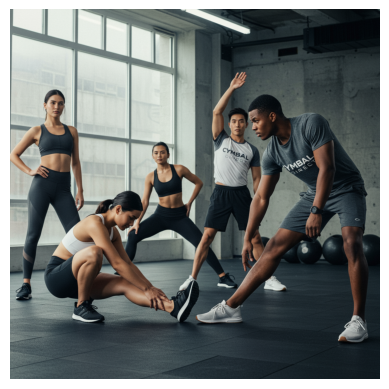

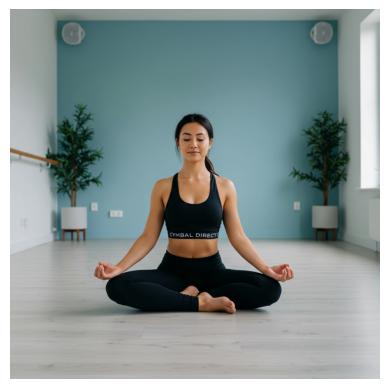

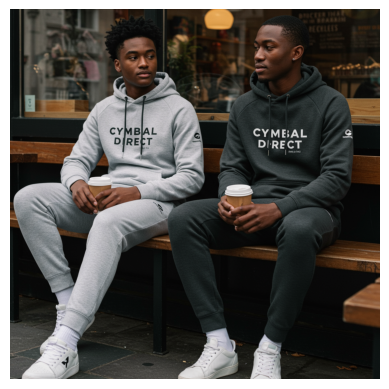

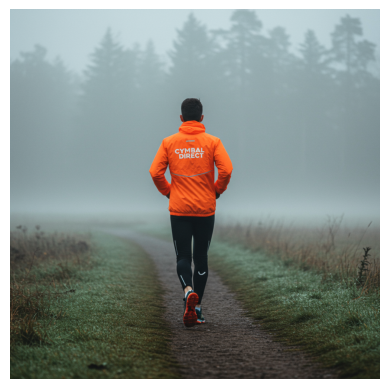

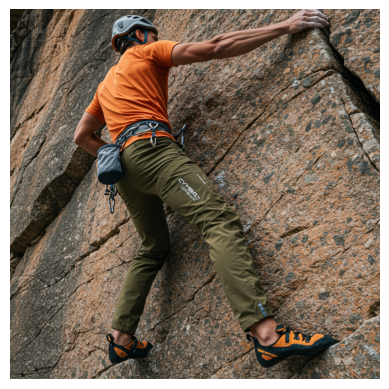

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Specify the directory where the images are stored
image_dir = 'media/images'

# Get a list of all image files in the directory
image_files = [f for f in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, f))]

# Display the images
for image_file in image_files:
    # Construct the full path to the image file
    image_path = os.path.join(image_dir, image_file)
    
    # Load the image
    img = mpimg.imread(image_path)
    
    # Display the image using Matplotlib
    plt.figure()  # Create a new figure for each image
    plt.imshow(img)
    plt.axis('off')  # Hide the axis
    plt.show()

### Initial Analysis with Gemini 3.5 Flash

For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Send the prompt and images to Gemini**.

In [12]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

In [13]:
# 1. Load the image data
image_folder = 'media/images'
image_files = [f for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]

# 2. Load the images into a list of `Part` objects
image_parts = []
for image_file in image_files:
    image_path = os.path.join(image_folder, image_file)
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    image_parts.append(Part.from_bytes(data=image_bytes, mime_type='image/jpeg'))  # Adjust mime_type if needed

# 3. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the images of Cymbal Direct's new athletic apparel line.
# The prompt should include clear instructions to:
# - Identify the apparel items in each image.
# - Describe the attributes of each item.
# - Identify any prominent style trends or preferences.
# 3. Construct the prompt for Gemini
prompt = """
Analyze the following images of Cymbal Direct's new athletic apparel line:
- Identify the apparel items shown in each image (shirts, leggings, shoes, accessories).
- Describe the attributes of each item (color, design, fit, style).
- Identify any prominent style trends or customer preferences across the images.
"""

# 4. Send the prompt and images to Gemini
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[prompt] + image_parts
)

# 5. Display the response
display(Markdown(response.text)) # TODO: Add your prompt here

# 4. Send the prompt and images to Gemini
# TODO: Use the `client.models.generate_content` method to send the prompt and images to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID` and the `contents` (including the prompt and image parts) as parameters.
# TODO: Store the response from the model in a variable named `response`.

# 5. Display the response
display(Markdown(response.text))

Based on the provided images, here is a detailed analysis of Cymbal Direct’s new athletic apparel line, categorized by image, followed by an analysis of overall style trends.

---

### **Image-by-Image Analysis**

#### **Image 1: Gym & Group Training**
*   **Apparel Items:** Sports bras, t-shirts, leggings, athletic shorts, sneakers, and accessories.
*   **Attributes:**
    *   **Women’s Tops:**
        *   *Grey/White/Black Sports Bras:* Cropped, snug-fit designs with clean necklines (scoop and racerback styles). They emphasize comfort, support, and minimalist styling.
    *   **Women’s Bottoms:**
        *   *Dark Grey & Black Leggings:* High-waisted, compression-fit, ankle-length. Feature subtle panelling for muscle support.
        *   *Black Bike Shorts:* Tight-fitting, mid-thigh length, designed for high-mobility training.
    *   **Men’s Tops:**
        *   *Two-Tone Raglan Tee (center background):* Light grey body with dark grey short sleeves. Features "CYMBAL DIRECT" in bold, clean block letters on the chest. Athletic fit.
        *   *Heather Charcoal Tee (front right):* Monochromatic dark grey heathered fabric, athletic fit, with "CYMBAL DIRECT" chest branding.
    *   **Men’s Bottoms:**
        *   *Black & Heather Charcoal Shorts:* Relaxed but structured fit, sitting slightly above the knee.
    *   **Shoes & Accessories:**
        *   *Sneakers:* Lightweight athletic trainers in contrasting black/white and light grey knit materials.
        *   *Accessory:* A sleek, black digital sports watch worn by the man on the right.

#### **Image 2: Yoga & Meditation**
*   **Apparel Items:** Sports bra and leggings.
*   **Attributes:**
    *   **Top (Sports Bra):** Classic black scoop-neck sports bra with a wide elastic underband. The underband features prominent white knit-in branding that reads "CYMBAL DIRECT".
    *   **Bottoms (Leggings):** Matte black, high-waisted, seamless leggings. They offer a highly compressive, second-skin fit suitable for low-impact movement and stretching.
    *   **Style:** Minimalist, monochromatic, and sleek.

#### **Image 3: Streetwear & Lifestyle**
*   **Apparel Items:** Hoodies, joggers, and lifestyle sneakers.
*   **Attributes:**
    *   **Tops (Hoodies):** Classic pullover hoodies with drawstrings and kangaroo pockets. Available in light heather grey and dark charcoal. Both feature "CYMBAL DIRECT" printed in contrasting block letters across the chest. The fit is relaxed but tailored (not oversized).
    *   **Bottoms (Joggers):** Matching slim-fit joggers in light grey and dark charcoal. They feature tapered legs with ribbed ankle cuffs and a subtle logo on the upper thigh.
    *   **Shoes:** Minimalist, retro-style white leather low-top sneakers with clean silhouettes.
    *   **Style:** Classic "athleisure" or streetwear; cozy, matching sweatsuits designed for casual everyday wear.

#### **Image 4: Outdoor Running**
*   **Apparel Items:** Windbreaker jacket, running tights, and running shoes.
*   **Attributes:**
    *   **Top (Jacket):** Vibrant neon orange hooded windbreaker. Features a lightweight, water-resistant look, a horizontal reflective safety strip across the back, and the "CYMBAL DIRECT" logo printed in bold white on the upper back.
    *   **Bottoms (Tights):** Sleek, full-length black compression running tights with subtle reflective graphics near the ankles for low-light safety.
    *   **Shoes:** Performance running shoes with high-visibility orange/red outsoles.
    *   **Style:** Functional, high-visibility, technical outdoor gear.

#### **Image 5: Rock Climbing**
*   **Apparel Items:** T-shirt, climbing pants, climbing shoes, and safety gear.
*   **Attributes:**
    *   **Top (T-shirt):** Solid burnt orange/terracotta crewneck short-sleeve t-shirt. Standard athletic fit, made of breathable fabric.
    *   **Bottoms (Pants):** Olive green/earthy brown technical climbing pants. They have a slim-straight fit, reinforced stitching, and a tapered ankle. A stylized, vertical "CYMBAL" logo is printed on the thigh.
    *   **Shoes:** Technical rock-climbing shoes with tight, asymmetrical lacing and high-friction black and yellow rubber.
    *   **Accessories:** Grey safety helmet, a chalk bag attached to the waist, and a climbing harness with carabiners.
    *   **Style:** Rugged, utilitarian, and outdoor-adventure focused.

---

### **Prominent Style Trends & Customer Preferences**

1.  **The "Athleisure" Crossover:**
    The line successfully bridges the gap between high-performance athletic gear (running, climbing, gym training) and casual lifestyle streetwear (the matching hoodie/jogger sets). This reflects a strong consumer preference for versatile clothing that transitions seamlessly from a workout to daily errands.

2.  **Sophisticated Color Palettes:**
    *   **The Core Neutrals:** A heavy reliance on muted, earthy, and monochromatic tones (black, charcoal, light grey, and olive green) conveys a modern, premium feel.
    *   **High-Visibility Accents:** Bright, saturated colors like neon orange and terracotta are used intentionally for outdoor safety and visual interest.

3.  **Clean, Modern Branding:**
    The branding is consistently executed with a clean, sans-serif typeface. Logo placements are highly strategic and trendy—appearing on sports bra underbands, vertically on pant thighs, and boldly across the back of jackets.

4.  **Tapered, Tailored Silhouettes:**
    Across both men's and women's apparel, there is a clear preference for slim, body-skimming, and tapered cuts (high-waisted compression leggings, slim joggers, and tailored-fit hoodies) rather than baggy, traditional athletic fits.

Based on the provided images, here is a detailed analysis of Cymbal Direct’s new athletic apparel line, categorized by image, followed by an analysis of overall style trends.

---

### **Image-by-Image Analysis**

#### **Image 1: Gym & Group Training**
*   **Apparel Items:** Sports bras, t-shirts, leggings, athletic shorts, sneakers, and accessories.
*   **Attributes:**
    *   **Women’s Tops:**
        *   *Grey/White/Black Sports Bras:* Cropped, snug-fit designs with clean necklines (scoop and racerback styles). They emphasize comfort, support, and minimalist styling.
    *   **Women’s Bottoms:**
        *   *Dark Grey & Black Leggings:* High-waisted, compression-fit, ankle-length. Feature subtle panelling for muscle support.
        *   *Black Bike Shorts:* Tight-fitting, mid-thigh length, designed for high-mobility training.
    *   **Men’s Tops:**
        *   *Two-Tone Raglan Tee (center background):* Light grey body with dark grey short sleeves. Features "CYMBAL DIRECT" in bold, clean block letters on the chest. Athletic fit.
        *   *Heather Charcoal Tee (front right):* Monochromatic dark grey heathered fabric, athletic fit, with "CYMBAL DIRECT" chest branding.
    *   **Men’s Bottoms:**
        *   *Black & Heather Charcoal Shorts:* Relaxed but structured fit, sitting slightly above the knee.
    *   **Shoes & Accessories:**
        *   *Sneakers:* Lightweight athletic trainers in contrasting black/white and light grey knit materials.
        *   *Accessory:* A sleek, black digital sports watch worn by the man on the right.

#### **Image 2: Yoga & Meditation**
*   **Apparel Items:** Sports bra and leggings.
*   **Attributes:**
    *   **Top (Sports Bra):** Classic black scoop-neck sports bra with a wide elastic underband. The underband features prominent white knit-in branding that reads "CYMBAL DIRECT".
    *   **Bottoms (Leggings):** Matte black, high-waisted, seamless leggings. They offer a highly compressive, second-skin fit suitable for low-impact movement and stretching.
    *   **Style:** Minimalist, monochromatic, and sleek.

#### **Image 3: Streetwear & Lifestyle**
*   **Apparel Items:** Hoodies, joggers, and lifestyle sneakers.
*   **Attributes:**
    *   **Tops (Hoodies):** Classic pullover hoodies with drawstrings and kangaroo pockets. Available in light heather grey and dark charcoal. Both feature "CYMBAL DIRECT" printed in contrasting block letters across the chest. The fit is relaxed but tailored (not oversized).
    *   **Bottoms (Joggers):** Matching slim-fit joggers in light grey and dark charcoal. They feature tapered legs with ribbed ankle cuffs and a subtle logo on the upper thigh.
    *   **Shoes:** Minimalist, retro-style white leather low-top sneakers with clean silhouettes.
    *   **Style:** Classic "athleisure" or streetwear; cozy, matching sweatsuits designed for casual everyday wear.

#### **Image 4: Outdoor Running**
*   **Apparel Items:** Windbreaker jacket, running tights, and running shoes.
*   **Attributes:**
    *   **Top (Jacket):** Vibrant neon orange hooded windbreaker. Features a lightweight, water-resistant look, a horizontal reflective safety strip across the back, and the "CYMBAL DIRECT" logo printed in bold white on the upper back.
    *   **Bottoms (Tights):** Sleek, full-length black compression running tights with subtle reflective graphics near the ankles for low-light safety.
    *   **Shoes:** Performance running shoes with high-visibility orange/red outsoles.
    *   **Style:** Functional, high-visibility, technical outdoor gear.

#### **Image 5: Rock Climbing**
*   **Apparel Items:** T-shirt, climbing pants, climbing shoes, and safety gear.
*   **Attributes:**
    *   **Top (T-shirt):** Solid burnt orange/terracotta crewneck short-sleeve t-shirt. Standard athletic fit, made of breathable fabric.
    *   **Bottoms (Pants):** Olive green/earthy brown technical climbing pants. They have a slim-straight fit, reinforced stitching, and a tapered ankle. A stylized, vertical "CYMBAL" logo is printed on the thigh.
    *   **Shoes:** Technical rock-climbing shoes with tight, asymmetrical lacing and high-friction black and yellow rubber.
    *   **Accessories:** Grey safety helmet, a chalk bag attached to the waist, and a climbing harness with carabiners.
    *   **Style:** Rugged, utilitarian, and outdoor-adventure focused.

---

### **Prominent Style Trends & Customer Preferences**

1.  **The "Athleisure" Crossover:**
    The line successfully bridges the gap between high-performance athletic gear (running, climbing, gym training) and casual lifestyle streetwear (the matching hoodie/jogger sets). This reflects a strong consumer preference for versatile clothing that transitions seamlessly from a workout to daily errands.

2.  **Sophisticated Color Palettes:**
    *   **The Core Neutrals:** A heavy reliance on muted, earthy, and monochromatic tones (black, charcoal, light grey, and olive green) conveys a modern, premium feel.
    *   **High-Visibility Accents:** Bright, saturated colors like neon orange and terracotta are used intentionally for outdoor safety and visual interest.

3.  **Clean, Modern Branding:**
    The branding is consistently executed with a clean, sans-serif typeface. Logo placements are highly strategic and trendy—appearing on sports bra underbands, vertically on pant thighs, and boldly across the back of jackets.

4.  **Tapered, Tailored Silhouettes:**
    Across both men's and women's apparel, there is a clear preference for slim, body-skimming, and tapered cuts (high-waisted compression leggings, slim joggers, and tailored-fit hoodies) rather than baggy, traditional athletic fits.

### Reasoning on image trends with Gemini 3.5 Flash

You'll now use Gemini thinking to perform a more in-depth analysis of the visual elements, inferring context, target audience, and potential marketing implications.

For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Use Gemini Thinking for deeper reasoning**.

In [15]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

In [17]:
# 1. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the images in more detail.
# The prompt should include clear instructions to:
# - Develop a hypothesis about the target audience for each image.
# - Analyze how visual elements contribute to the overall message and appeal.
# - Compare the observed style trends with broader fashion trends in athletic wear.
# - Provide recommendations for Cymbal Direct's future marketing campaigns or product development.
# 1. Construct the prompt for Gemini
# 1. Construct the prompt for Gemini
thinking_mode_prompt = """
Perform a deeper analysis of the Cymbal Direct apparel images:
- Develop a hypothesis about the target audience for each image (age, gender, lifestyle, fitness level).
- Analyze how visual elements (colors, poses, backgrounds, models) contribute to the overall brand message.
- Compare style trends observed with broader athletic wear industry trends.
- Provide actionable recommendations for future marketing campaigns or product development.
"""

# 2. Send the prompt and images to the Gemini Thinking model
thinking_model_response = client.models.generate_content(
    model=MODEL_ID,
    contents=[thinking_mode_prompt] + image_parts,
    config=config
)

# 3. Print thoughts and answer
print_thoughts(thinking_model_response)

# 4. Save the image analysis to a file
with open('analysis/image_analysis.md', 'w') as f:
    f.write(thinking_model_response.text)
# 2. Use Gemini thinking for deeper reasoning
# TODO: Use the `client.models.generate_content` method to send the thinking_mode_prompt and images to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID`, `contents` (including the prompt and image parts), and `config` to enable thinking mode.
# TODO: Store the response from the model in a variable named `thinking_model_response_image`.

## Thoughts:
**My Deep Dive into the Cymbal Direct Apparel Imagery**

Okay, I've been tasked with a really interesting deep dive into these five Cymbal Direct apparel images. My goal is to thoroughly dissect them, moving from an initial intuitive understanding to a strategic, actionable conclusion. Essentially, I'm putting myself in the brand's shoes and then looking outwards at the market.

Here's how my thought process unfolded:

**1. Deconstructing the Core Request:**

First, I made sure I understood *exactly* what was being asked of me. The prompt is clear:
*   Analyze five distinct apparel images.
*   For *each* image, hypothesize the target audience, detailing age, gender, lifestyle, and fitness level.
*   Then, I need to dissect the visual elements – colors, poses, backgrounds, and models – and explain how they collectively craft the brand's message.
*   Following that, I'm to compare the stylistic trends I observe within these images to the broader athletic wear industry.
*   Finally, the crucial part: translate all this analysis into actionable recommendations for future marketing campaigns or even product development.

This isn't just a surface-level look; it requires a comprehensive, strategic, and marketing-oriented perspective.

**2. The Initial Visual Scan: Image-by-Image Breakdown**

My first pass involved looking at each image independently, jotting down immediate impressions and keywords. This is where the audience hypotheses really start to form.

*   **Image 1: Gym Group Stretching**
    *   *What I See:* A diverse group (3 female, 2 male, good racial mix) in a modern, industrial-feeling gym. The lighting is high-contrast, really highlighting the forms and the gear. They're in dynamic stretches, some looking instructional or collaborative.
    *   *The Gear:* Mostly dark, muted tones – grays, blacks, whites, heather textures. The "Cymbal Direct" logo is subtle, on the t-shirts. It's functional, minimalist athletic wear – sports bras, leggings, shorts.
    *   *My Hypothesis:* This screams Gen Z or young Millennials (let's say 20-35). It's co-ed, definitely targeting people with a high fitness level – the bodies are lean and muscular. The lifestyle is structured, communal fitness – think CrossFit, group classes, or personal training sessions.

*   **Image 2: Yoga Solo Woman**
    *   *What I See:* A single female model, appearing to be of Asian descent, in a very serene, minimalist indoor studio. A muted teal wall, light wood floors, a couple of plants. The composition is central and balanced, and the pose is calm, meditative.
    *   *The Gear:* A sleek, all-black matching set – sports bra and high-waist leggings. The "CYMBAL DIRECT" branding is bold and white, strategically placed on the sports bra band.
    *   *My Hypothesis:* This resonates with Millennial or Gen Z females (around 22-38). The lifestyle is about holistic wellness – yoga, mindfulness, self-care. Fitness level is likely moderate to high, but the emphasis here is on flexibility and mental well-being, not just brute strength.

*   **Image 3: Urban Lifestyle Men**
    *   *What I See:* Two Black male models are sitting on an outdoor bench, casually holding coffee cups in what looks like an urban café setting. Their poses are relaxed, easy. The background is a warm, inviting urban storefront.
    *   *The Gear:* Coordinated sweatsuits – one light grey, one dark grey/charcoal. The "CYMBAL DIRECT" branding is prominent, large on the chest. This is clearly athleisure and streetwear.
    *   *My Hypothesis:* Targeting young adult males, perhaps 18-30. Their lifestyle is urban, social, and they clearly value comfort mixed with streetwear trends – think athleisure, maybe a touch of "gorpcore" street style. Fitness level is likely moderate or general.

*   **Image 4: Outdoor Foggy Runner**
    *   *What I See:* A lone male model, viewed from behind, running on a dirt trail. The background is a misty, foggy forest. The colors are high-contrast, and the overall mood is one of isolation, determination, and immersion in nature.
    *   *The Gear:* A bright, neon orange windbreaker/running jacket with "CYMBAL DIRECT" in white on the back, paired with black running tights.
    *   *My Hypothesis:* This is for adult males, likely 25-45. They're serious runners or outdoor enthusiasts. Fitness level is high, and they value discipline, safety (that high-vis jacket is key), and high-performance, weather-resistant gear.

*   **Image 5: Rock Climber**
    *   *What I See:* A single male model actively climbing a steep rock face. It's an action shot, mid-climb. He's wearing a helmet and has a chalk bag visible. The environment is natural and rugged. The color palette is warm and earthy.
    *   *The Gear:* A bright orange t-shirt, olive green technical climbing pants with "Cymbal" branding, and climbing shoes.
    *   *My Hypothesis:* This targets young to middle-aged adults (20-40, and while this model is male, it has broad appeal). It's about an extreme sports or outdoor adventure lifestyle – climbing, hiking, bouldering. Fitness level is high, focusing on functional strength and agility.

**3. Synthesizing the Visual Language and Brand Message:**

Now, I zoom out. Instead of just looking at individual images, I'm asking: *What story are these visuals telling together?*

*   **Color Palette:** I see a clear transition. It starts with neutrals and minimalist tones in the gym and yoga settings, moves to more casual, comfortable colors for urban streetwear, and then shifts to high-visibility and earthy, natural tones for outdoor activities. This suggests versatility.
*   **Poses and Action:** We have a spectrum: communal effort and instruction (Image 1), serene self-practice (Image 2), relaxed social interaction (Image 3), focused solitary exertion (Image 4), and peak physical challenge (Image 5).
*   **Environments:** This is key. We go from the controlled, modern gym to the peaceful sanctuary of a studio, to the social buzz of the city, and finally to the raw power of nature (trail and rock face).
*   **Models:** The models are diverse, athletic but attainable, and represent a younger, active demographic.
*   **The Collective Brand Message:** When I stitch these elements together, Cymbal Direct emerges as an all-encompassing lifestyle and performance brand. It supports its wearers in *every* aspect of their physical lives. It's for those seeking inner peace, pushing boundaries outdoors, training within a community, or simply recovering and socializing comfortably. The tagline I'd pull from this is: "From the studio to the street, to the wild – Cymbal Direct has you covered."

**4. Benchmarking Against Industry Trends:**

I'm now cross-referencing what I see with what's happening with the big players – Lululemon, Nike, Gymshark, Arc'teryx, Alo Yoga, etc.

*   **Athleisure & Streetwear Integration:** Image 3 perfectly nails the trend of athletic wear bleeding into everyday fashion. The matching sweatsuits are a direct nod to this.
*   **Outdoor Performance / "Gorpcore":** Images 4 and 5 tap directly into the rising popularity of technical outdoor gear for everyday wear and for serious enthusiasts. The functional jackets and durable pants are spot on.
*   **Minimalist Aesthetic & Monochromatic Sets:** Images 1 and 2 showcase the enduring appeal of clean lines, neutral palettes, and coordinated sets, which many brands, from Alo Yoga to Lululemon, champion.
*   **Visible, Bold Branding:** The prominent branding on the yoga bra band and the sweatsuits aligns with a Gen Z preference for clear brand identity and logowear, a trend Gymshark has capitalized on significantly.

Cymbal Direct seems to be hitting several key contemporary trends, which is a good sign.

**5. Forging Actionable Recommendations:**

Based on all of this analysis, what concrete steps can the brand take? This is where the strategic value lies.

*   **Recommendation 1: Segmented Marketing & Product Lines:** The images clearly show different use cases. I'd advise segmenting marketing efforts and potentially even product lines more explicitly. Think:
    *   **"Cymbal Performance"**: For the serious runners and climbers (Images 4 & 5). Focus on technical specs, durability, weather resistance.
    *   **"Cymbal Studio"**: For yoga and wellness (Image 2). Emphasize comfort, flexibility, soft fabrics, and mindful aesthetics.
    *   **"Cymbal Club" / "Cymbal Street"**: For athleisure and urban lifestyle (Image 3). Highlight comfort, style, and versatility for social settings.
    *   **"Cymbal Collective"**: For group fitness and community (Image 1). Focus on shared experience, inclusive sizing, and durable, functional gear.
    *   *Why?* This allows for more targeted messaging, ensuring the right product reaches the right audience, preventing dilution of brand perception.

*   **Recommendation 2: Double Down on the "Outdoor Adventure" Narrative:** Images 4 and 5 are incredibly compelling and tap into a growing market segment. The bright orange jacket and the technical climbing pants are strong visual anchors. Cymbal Direct should seriously lean into this "gorpcore" or outdoor performance narrative. Feature more extreme sports, rugged landscapes, and highlight the technical innovation of their gear. This could position them as a premium outdoor brand.

*   **Recommendation 3: Cultivate Community-Driven Campaigns:** Image 1 and 3 beautifully illustrate connection – group training and casual hangouts. The brand should actively foster this. Consider launching "Cymbal Clubs," local fitness challenges, or user-generated content campaigns that showcase real people in their communities wearing Cymbal. This builds authenticity and loyalty.

*   **Recommendation 4: Amplify Sustainability Stories (Especially for Outdoor Gear):** Given the strong emphasis on natural environments in Images 4 and 5, there's a massive opportunity to weave in sustainability. If they use recycled materials (like recycled polyester for the running jacket) or organic cotton for sweats, they need to make that a central part of their story, especially to the outdoor-focused consumer who often cares deeply about environmental impact. This isn't just good PR; it's a genuine selling point for this demographic.

By breaking down the visuals so meticulously and then relating them to broader market forces, I feel I've arrived at a robust understanding and a set of strategic pathways for Cymbal Direct.



## Answer:
This is a comprehensive analysis of the five Cymbal Direct apparel images, broken down into target audience hypotheses, visual element evaluation, industry trend comparisons, and actionable brand recommendations.

---

### 1. Target Audience Hypotheses (Image-by-Image)

#### Image 1: Co-ed Gym Training Group
*   **Age:** Gen Z to Young Millennials (18–30).
*   **Gender:** Co-ed (appealing equally to men and women).
*   **Lifestyle:** High-energy, social, communal. These individuals likely participate in group fitness classes, CrossFit, HIIT, or personal training sessions. They value community, peer motivation, and aesthetic gym environments.
*   **Fitness Level:** Advanced to Elite. The models display highly toned, athletic, and muscular builds, performing deep stretches and athletic stances.

#### Image 2: Solo Yoga Studio
*   **Age:** Millennials (25–40).
*   **Gender:** Female-focused (though appealing to anyone interested in mindfulness).
*   **Lifestyle:** Holistic wellness, self-care, and mindfulness-driven. She likely prioritizes mental health, clean eating, and work-life balance. She values quiet luxury, aesthetics, and minimalist living.
*   **Fitness Level:** Intermediate to Advanced (specifically in flexibility, core strength, and low-impact mobility).

#### Image 3: Urban Lifestyle / Streetwear Hangout
*   **Age:** Gen Z (16–25).
*   **Gender:** Male-focused.
*   **Lifestyle:** Urban, social, and fashion-conscious. They hang out at local coffee shops, value comfort, and treat athletic wear as daily streetwear. Fitness is integrated into a broader social lifestyle rather than being the sole focus.
*   **Fitness Level:** Moderate/General. The focus here is on comfort, recovery, and post-workout leisure rather than active exertion.

#### Image 4: Misty Trail Runner
*   **Age:** Adults (28–48).
*   **Gender:** Male (with broad appeal to solo outdoor athletes).
*   **Lifestyle:** Disciplined, solitary, and nature-oriented. This individual is willing to wake up early and run in harsh, cold, or foggy conditions. They value endurance, mental toughness, and high-performance, weather-resistant gear.
*   **Fitness Level:** Elite / High-Endurance. Running on uneven terrain in wet conditions requires high cardiovascular fitness and joint stability.

#### Image 5: Rock Climber
*   **Age:** Young to Middle-aged Adults (22–38).
*   **Gender:** Male (but appeals to the broader co-ed outdoor adventure community).
*   **Lifestyle:** "Gorpcore" / Outdoor adventure. They spend weekends traveling to national parks, bouldering, camping, and seeking adrenaline. They value durable, highly functional utility wear.
*   **Fitness Level:** High Functional Strength. Rock climbing requires immense upper body strength, grip strength, flexibility, and lean muscle mass.

---

### 2. Visual Elements & Brand Message Analysis

```
+---------------------------------------------------------------------------------+
|                                 CYMBAL DIRECT                                   |
|                        "Every Athlete, Every Environment"                       |
+------------------------+------------------------+-------------------------------+
|       PERFORMANCE      |        WELLNESS        |           LIFESTYLE           |
| (Gym / Running / Climb)|         (Yoga)         |          (Streetwear)         |
+------------------------+------------------------+-------------------------------+
```

#### Color Palettes
*   **Analysis:** The brand utilizes a dual-strategy color palette. On one hand, it relies on minimalist neutrals (charcoal, heather grey, matte black) for the gym, yoga, and lifestyle lines. On the other hand, it uses high-visibility, safety, and nature-inspired colors (neon safety orange, olive green, earthy stone) for outdoor running and climbing.
*   **Brand Message:** Cymbal Direct is highly adaptable. It can be subtle and sophisticated in the studio, but functional and high-visibility when safety and durability are required in the wild.

#### Poses & Action
*   **Analysis:** Poses transition seamlessly from **active exertion** (climbing a rock face, running a trail), to **active preparation** (dynamic stretching in the gym), to **receptive stillness** (meditating on the floor), to **complete relaxation** (drinking coffee on a bench).
*   **Brand Message:** The brand supports the entire "athletic loop"—preparation, performance, mindfulness, and recovery.

#### Backgrounds & Environments
*   **Analysis:** The backdrops range from highly manufactured, clean environments (the minimalist blue studio and the industrial concrete gym) to gritty urban cafes and raw, foggy, rocky nature.
*   **Brand Message:** "We are not just a gym brand." Cymbal Direct positions itself as a 360-degree lifestyle brand capable of transitioning from indoor urban spaces to extreme outdoor elements.

#### Models & Representation
*   **Analysis:** The cast of models is highly diverse in ethnicity, reflecting a modern, global consumer base. They look fit, healthy, and aspirational, but remain approachable rather than hyper-intimidating.
*   **Brand Message:** Inclusivity, modern athleticism, and global community.

---

### 3. Style Trends vs. Broad Athletic Wear Industry Trends

Cymbal Direct's aesthetic aligns closely with major shifts in the activewear market, mirroring strategies used by industry giants like **Lululemon, Gymshark, Nike, and Arc'teryx**:

*   **The "Gorpcore" and Outdoor Utility Boom (Images 4 & 5):**
    *   *Trend:* Consumers are demanding athletic wear that doubles as rugged outdoor gear. Brands like Salomon and Arc'teryx have become streetwear icons.
    *   *Cymbal Direct Alignment:* The olive green climbing pants and neon windbreaker show a clear move into technical, weather-resistant utility wear that bridges the gap between extreme sports and lifestyle fashion.
*   **Athleisure as Daily Uniform (Image 3):**
    *   *Trend:* Post-pandemic, matching fleece sweat sets have replaced casual denim for Gen Z and Millennials.
    *   *Cymbal Direct Alignment:* The monochromatic, clean-branded hoodies and joggers represent the "cozy streetwear" trend, designed for cafes, travel, and recovery days.
*   **Symmetry and Mindful Aesthetics (Image 2):**
    *   *Trend:* Wellness brands (e.g., Alo Yoga) focus heavily on pastel/earthy tones, clean symmetrical framing, and minimalist branding to evoke a sense of peace.
    *   *Cymbal Direct Alignment:* The muted teal wall, balanced plants, and centered yoga pose lean heavily into the "wellness-as-an-aesthetic" trend.
*   **Bold Typographic Branding (Images 1, 2, & 3):**
    *   *Trend:* A shift away from obscure logos back to bold, clean, sans-serif wordmarks (similar to the rise of Gymshark or Under Armour's modernized branding).
    *   *Cymbal Direct Alignment:* Placing "CYMBAL DIRECT" in high-contrast block text on sports bra bands, sweatshirt chests, and jacket backs turns the consumer into a walking brand billboard.

---

### 4. Actionable Recommendations for Marketing & Product Development

#### A. Product Development: Segment into Sub-Collections
Currently, Cymbal Direct runs the risk of trying to be "everything to everyone." To prevent brand dilution, split the product catalog into four distinct sub-brands:
1.  **Cymbal Studio (Yoga/Mindfulness):** Focus on buttery-soft fabrics, seamless construction, and muted pastel/earthy tones (expanding on Image 2).
2.  **Cymbal Iron (Gym/HIIT):** Focus on compression, sweat-wicking fabrics, and high-durability materials (expanding on Image 1).
3.  **Cymbal Summit (Outdoor/Run/Climb):** Focus on tear-resistant materials, wind/waterproofing, and high-visibility safety features (expanding on Images 4 & 5).
4.  **Cymbal Club (Streetwear/Recovery):** Heavyweight cotton hoodies, fleece joggers, and lifestyle tees (expanding on Image 3).

#### B. Marketing Campaign: "The Loop"
*   **Concept:** Launch an omni-channel campaign tracing a single athlete through "The Loop" of their week.
*   **Execution:** Show them training intensely (Iron), recovering with friends at a cafe (Club), finding mental clarity outdoors (Summit), and recentering via yoga (Studio).
*   **Tagline:** *"Find Your Rhythm."* (A play on the word "Cymbal" and the rhythm of athletic life).

#### C. Digital & Social Media Strategy
*   **For "Cymbal Club" (Gen Z):** Launch TikTok and Instagram Reel campaigns featuring "Get Ready With Me" (GRWM) style streetwear styling videos using the matching grey and charcoal sweat sets.
*   **For "Cymbal Summit" (Outdoor):** Partner with outdoor micro-influencers (climbers, trail runners) to do "weather-testing" videos in foggy, rainy, or rocky conditions to prove the technical quality of the orange windbreaker and climbing pants.

#### D. Sustainability Storytelling
*   Given the heavy focus on beautiful outdoor environments (misty forests, rock walls), the brand must match this visually with environmental responsibility.
*   **Action:** Ensure the "Cymbal Summit" outdoor line is marketed as being made from recycled ocean plastics or eco-conscious materials, aligning the product's construction with the natural playgrounds showcased in the imagery.

## Task 4. Analyze and reason on audio content: Customer perceptions

In this section, you will use Gemini to analyze a podcast about Cymbal Direct's new clothing line and extract information/sentiment out of it and use those to generate insights for the company. You will save the findings from the model into a markdown file that you will use for a comprehensive report in the last task.

**Your tasks will be labeled with a `#TODO` section in the cell. Read each cell carefully and ensure you are filling them out correctly!**

#### Introduction and Context
This audio clip is from a podcast episode featuring an interview with a Cymbal Direct representative discussing the new athletic apparel line. The conversation covers various aspects of the apparel, including design, features, target audience, and marketing strategy.

### Preview the podcast episode (optional)

To listen to the podcast episode, you can copy the file to your local environment and use iPython to preview it in the notebook.

In [ ]:
import IPython

!gcloud storage cp gs://{PROJECT_ID}-bucket/media/audio/cymbal_direct_expert_interview.wav \
media/audio/cymbal_direct_expert_interview.wav

IPython.display.Audio('media/audio/cymbal_direct_expert_interview.wav')

Copying gs://qwiklabs-gcp-01-422fd8fa63c5-bucket/media/audio/cymbal_direct_expert_interview.wav to file://media/audio/cymbal_direct_expert_interview.wav
  Completed files 1/1 | 41.9MiB/41.9MiB                                        

Average throughput: 88.5MiB/s


### Initial analysis with Gemini 3.5 Flash
For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Send the prompt and audio to Gemini**.

In [ ]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

In [ ]:
# Construct the file URI using f-string
file_uri = f"gs://{PROJECT_ID}-bucket/media/audio/cymbal_direct_expert_interview.wav"

audio_part = Part.from_uri(
    file_uri=file_uri,
    mime_type="audio/wav",
)

In [ ]:
# 1. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the audio recording of the conversation about Cymbal Direct's new athletic apparel line.
# The prompt should include clear instructions to:
# - Transcribe the conversation, identifying different speakers.
# - Provide a sentiment analysis, highlighting positive, negative, and neutral opinions.
# - Identify key themes and topics discussed, such as comfort, fit, performance, style, and comparisons to competitors.
# 1. Construct the prompt for Gemini
thinking_mode_prompt = """
Analyze this podcast audio about Cymbal Direct's new athletic apparel line:
1. Transcribe the conversation, clearly identifying different speakers.
2. Provide sentiment analysis highlighting positive, negative, and neutral opinions.
3. Identify key themes discussed (comfort, fit, performance, style, comparisons to competitors).
4. Summarize the overall perception of Cymbal Direct's new apparel line.
"""

# 2. Send the prompt and audio to Gemini
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[thinking_mode_prompt, audio_part]
)

# 3. Display the response
display(Markdown(response.text))

# 2. Send the prompt and audio to Gemini
# TODO: Use the `client.models.generate_content` method to send the thinking_mode_prompt and audio data to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID` and the `contents` (including the `audio_part` and the `prompt`) as parameters.
# TODO: Store the response from the model in a variable named `response`.


### Reasoning on Audio Insights with Gemini 3.5 Flash
In this section, you'll use Gemini thinking to analyze the conversation at a deeper level, reason about customer satisfaction, deduce influencing factors, and generate data-driven recommendations.

For this section, you will need to fill out the `#TODOs` for **Construct the prompt for Gemini** and **Use Gemini Thinking for deeper reasoning**.

In [ ]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

In [ ]:
# 1. Construct the prompt for Gemini
# TODO: Write a prompt that instructs the Gemini model to analyze the audio recording in more detail.
# The prompt should include clear instructions to:
# - Reason about the overall customer satisfaction with the apparel.
# - Deduce the key factors influencing customer perception.
# - Develop three data-driven recommendations for Cymbal Direct.
# - Identify any potential biases or limitations in the audio data.
# 1. Construct the prompt for Gemini
thinking_mode_prompt = """
Perform a deeper analysis of this Cymbal Direct podcast interview:
- Analyze customer satisfaction signals expressed or implied in the conversation.
- Deduce the key factors shaping public perception of the new apparel line.
- Identify risks or concerns raised and their potential impact on brand reputation.
- Generate three specific, data-driven recommendations for Cymbal Direct's marketing and product teams.
"""

# 2. Use Gemini thinking for deeper reasoning
thinking_model_response = client.models.generate_content(
    model=MODEL_ID,
    contents=[thinking_mode_prompt, audio_part],
    config=config
)

# 3. Print thoughts and answer
print_thoughts(thinking_model_response)

# 4. Save the audio analysis to a file
with open('analysis/audio_analysis.md', 'w') as f:
    f.write(thinking_model_response.text)

# 2. Use Gemini thinking for deeper reasoning
# TODO: Use the `client.models.generate_content` method to send the prompt and audio data to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID`, `contents` (including the `audio_part` and the `prompt`), and `config` to enable thinking mode.
# TODO: Store the response from the model in a variable named `thinking_model_response`.


## Task 5. Synthesize multimodal insights: Generate a comprehensive report

In this final task, you will synthesize the insights gained from your previous analyses of text, images, and audio data. You'll use the Gemini 3.5 Flash model to generate a comprehensive report that consolidates the findings from each modality, providing a holistic view of customer sentiment, style preferences, and key trends related to Cymbal Direct's new athletic apparel line.

You will save the final report generated by the model into a markdown file, which you will then upload to Cloud Storage for review and evaluation. This comprehensive report will serve as a valuable resource for Cymbal Direct, enabling them to make informed decisions and optimize their strategies based on a thorough understanding of customer perceptions and market trends.

**Your tasks will be labeled with a #TODO section in the cell. Read each cell carefully and ensure you are filling them out correctly!**


In [ ]:
MODEL_ID = "gemini-3.5-flash"  # @param {type: "string"}

In [ ]:
# 1. Load the analysis results from the files
with open('analysis/text_analysis.md', 'r') as f:
    text_analysis = f.read()

with open('analysis/image_analysis.md', 'r') as f:
    image_analysis = f.read()

with open('analysis/audio_analysis.md', 'r') as f:
    audio_analysis = f.read()

# 2. Combine the analysis results
all_analysis = f"""
## Text Analysis:
{text_analysis}

## Image Analysis:
{image_analysis}

## Audio Analysis:
{audio_analysis}
"""

# 3. Construct the prompt for Gemini
# TODO: Write a prompt to instruct the Gemini model to generate a comprehensive report based on the combined analysis results.
# The prompt should include clear instructions to:
# - Summarize the overall sentiment towards the new apparel line.
# - Identify key themes and trends in customer feedback.
# - Provide insights on style preferences, usage patterns, and customer behavior.
# - Evaluate the audio and its fit with the product image.
# - Offer actionable recommendations for Cymbal Direct to refine their marketing strategy and product positioning.
# 1. Load the analysis results from the files
with open('analysis/text_analysis.md', 'r') as f:
    text_analysis = f.read()

with open('analysis/image_analysis.md', 'r') as f:
    image_analysis = f.read()

with open('analysis/audio_analysis.md', 'r') as f:
    audio_analysis = f.read()

# 2. Combine the analysis results
all_analysis = f"""
## Text Analysis:
{text_analysis}

## Image Analysis:
{image_analysis}

## Audio Analysis:
{audio_analysis}
"""

# 3. Construct the prompt for Gemini
comprehensive_report_prompt = f"""
You are a senior marketing analyst at Cymbal Direct. Based on the following combined analysis 
from text, image, and audio data about the new athletic apparel line, generate a comprehensive report that:
- Summarizes the overall sentiment towards the new apparel line.
- Identifies key themes and trends in customer feedback.
- Provides insights on style preferences, usage patterns, and customer behavior.
- Evaluates the audio and its fit with the product image.
- Offers actionable recommendations for Cymbal Direct to refine their marketing strategy and product positioning.

Format the output as a professional Markdown report with clear headings and sections.

{all_analysis}
"""

# 4. Send the prompt to Gemini
thinking_model_response = client.models.generate_content(
    model=MODEL_ID,
    contents=comprehensive_report_prompt,
    config=config
)

# 5. Print the thoughts and answer
print_thoughts(thinking_model_response)

# 6. Save the final report to a file
with open('analysis/final_report.md', 'w') as f:
    f.write(thinking_model_response.text)
# 4. Send the prompt to Gemini
# TODO: Use the `client.models.generate_content` method to send the comprehensive_report_prompt to the Gemini model.
# TODO: Make sure to specify the `MODEL_ID`, the `comprehensive_report_prompt`, and the `config` to enable thinking mode.
# TODO: Store the response from the model in a variable named `thinking_model_response`.

In [ ]:
!gcloud storage cp analysis/final_report.md gs://{PROJECT_ID}-bucket/analysis/final_report.md

## Congratulations!

Congratulations! In this lab, you have successfully utilized the Gemini 3.5 Flash model with reasoning capabilities to analyze multimodal data, including text, images, and audio, to gain valuable insights for Cymbal Direct's new athletic apparel line. You have demonstrated proficiency in constructing effective prompts, leveraging the reasoning capabilities of Gemini thinking, and generating a comprehensive report with actionable recommendations.

Copyright 2025 Google LLC All rights reserved. Google and the Google logo are trademarks of Google LLC. All other company and product names may be trademarks of the respective companies with which they are associated.